## Introduction

In this code, the Land Surface Temperature (LST) is computed using the thermal band (band 10) of Landsat 8 - Landsat Collection 2 Level 2 Dataset. Rather than modifying this (thermal), one can also use the values of the band as a direct measure for LST. 

This code is written in geemap. The code is largely based on the code of Ujaval Gandhi (2021, supplement) for the "Derive LST from Landsat Images'.

In this script, the Python geemap package is used. In order to convert the JavaScript (JS) code of Google Earth Engine (GEE) into geemap, we used the conversion Python command ["Geemap "geemap.js_snippet_to_py" command"](https://book.geemap.org/chapters/03_gee_data.html#converting-javascript-to-python) that is available in the geemap package. 

## Importing the libraries

In [1]:
from pathlib import Path

import ee
import geemap
import geopandas as gpd
import pandas as pd

In [ ]:
cloud_project = 'FILL IN YOUR CLOUD PROJECT'

try:
    ee.Initialize(project=cloud_project)
except:
    ee.Authenticate()
    ee.Initialize(project=cloud_project)

## Reading in and preparing the data

In [3]:
# Define the paths
BASE_DIR = Path.cwd().parent
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


In [4]:
## Detailed wards
df_inpath = PROCESSED_DIR / "bang_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\bang_fix_mapshaper.shp


In [5]:
# https://geemap.org/notebooks/10_shapefiles/ 
# Convert to something geemap can understand
bangalore = geemap.shp_to_ee(df_inpath)

In [6]:
print(f'The number of wards in Bangalore is {bangalore.size().getInfo()}')

The number of wards in Bangalore is 369


In [7]:
bangGeometry = bangalore.union(50)

Map = geemap.Map()
Map.centerObject(bangGeometry, zoom=10)
Map # Uncomment if you want to see the map. 
## Otherwise you can wait till later Maps as all layers are in them

Map(center=[12.976321081394412, 77.6029786933227], controls=(WidgetControl(options=['position', 'transparent_b…

In [8]:
Map.addLayer(bangGeometry, {}, 'Bangalore outline')
Map

Map(center=[12.976321081394412, 77.6029786933227], controls=(WidgetControl(options=['position', 'transparent_b…

In [9]:
## Add the ward data
image = ee.Image().paint(bangalore, 0, 2)
Map.addLayer(image, {'palette': 'red'}, "Bangalore geometry")
Map

Map(center=[12.976321081394412, 77.6029786933227], controls=(WidgetControl(options=['position', 'transparent_b…

## Computing the Land Surface Temperature

In [10]:
# https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC08_C02_T1_L2#colab-python
# Applies scaling factors.
# def apply_scale_factors(image):
#   optical_bands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
#   thermal_bands = image.select('ST_B.*').multiply(0.00341802).add(149.0)
#   return image.addBands(optical_bands, None, True).addBands(
#       thermal_bands, None, True
#   )

In [10]:
colThsummer = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
.filterBounds(bangGeometry) \
.filterDate('2024-01-01', '2025-11-01') \
.filter(ee.Filter.calendarRange(3, 5, 'month')) 

In [14]:
## colThsummer

In [11]:
def maskL8sr(image):
    ## Code obtained from:
    ## https://courses.spatialthoughts.com/end-to-end-gee-supplement.html#derive-lst-from-landsat-images 
    qaMask = image.select('QA_PIXEL').bitwiseAnd(int('11111', 2)).eq(0)
    saturationMask = image.select('QA_RADSAT').eq(0)

    # Scaling factors
    opticalBands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    thermalBands = image.select('ST_B.*').multiply(0.00341802).add(149.0)

    # Replace the original bands with the scaled ones and apply the masks.
    return image.addBands(opticalBands, None, True) \
    .addBands(thermalBands, None, True) \
    .updateMask(qaMask) \
    .updateMask(saturationMask)


In [12]:
colThsummer = colThsummer.map(maskL8sr)
## colThsummer

In [13]:
imageThsummer = colThsummer.median()
imageThsummer

In [14]:
image_clipped = imageThsummer.clip(bangGeometry)

visualisation = {
  'bands': ['SR_B4', 'SR_B3', 'SR_B2'], 
  'min': 0,
  'max': 0.5,
  'gamma': [0.95, 1.1, 1]
}

Map.addLayer(image_clipped, visualisation, 'True Color Composite Bangalore')

Map

Map(center=[12.976321081394412, 77.6029786933227], controls=(WidgetControl(options=['position', 'transparent_b…

In [15]:
thermalsummer = imageThsummer.select('ST_B10') \
.clip(bangGeometry) \

Map.addLayer(thermalsummer, {
"min": 280,
"max": 330,
"palette": ['blue', 'white', 'red']},'Landsat_BT')

Map

Map(center=[12.976321081394412, 77.6029786933227], controls=(WidgetControl(options=['position', 'transparent_b…

In [17]:
## Convert to Celsius
thermal_summer_c = (
thermalsummer
.clip(bangGeometry)
.subtract(273.15)
.rename('LST_C')
)

In [18]:
Map.addLayer(thermal_summer_c, {
    "min": 35,
    "max": 42,
    "palette": ['blue', 'white', 'red'],
},
'LST_Landsat')

vis_params = {'min': 35, 'max': 42, 'palette': ['blue', 'white', 'red']}
Map.add_colorbar(vis_params, label='Land Surface Temperature (°C)',position= 'bottomleft')
Map

Map(center=[12.976321081394412, 77.6029786933227], controls=(WidgetControl(options=['position', 'transparent_b…

## Zonal statistics for LST

In [19]:
lstwardsmanualsummer = thermal_summer_c.reduceRegions(
collection=bangalore,
reducer=ee.Reducer.mean(),
scale=30,
)

In [23]:
## lstwardsmanualsummer

In [24]:
lstwardsmanualsummer = lstwardsmanualsummer.select(['ward_id', 'ward_name', 'mean'])

In [25]:
outdir = PROCESSED_DIR /'lstband10summer_bang.csv'
print(outdir)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\lstband10summer_bang.csv


In [26]:
geemap.ee_export_vector(lstwardsmanualsummer, outdir, verbose=True)

Generating URL ...
Please wait ...
Data downloaded to C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\lstband10summer_bang.csv


In [27]:
df_lst_mean_summer = pd.read_csv(outdir)

In [28]:
df_lst_mean_summer

,system:index,ward_name,mean,ward_id
0,0,25 - Vinayaka Layout,39.324657,25
1,1,2 - Aerocity,38.621582,2
2,2,3 - Chowdeshwari ward,38.597490,3
3,3,15 - Ramamurthy Nagara,38.432678,15
4,4,58 - Nagashettyhalli,37.427218,58
...,...,...,...,...
364,364,56 - Gopalpura,39.079316,56
365,365,57 - Cottonpete,40.597494,57
366,366,54 - Binnypete,39.749570,54
367,367,47 - IPD Salappa Ward,39.408972,47


In [29]:
print(f"The minimum temperature is {df_lst_mean_summer['mean'].min()}.")
print(f"The maximum temperature is {df_lst_mean_summer['mean'].max()}.")

The minimum temperature is 35.593766695678646.
The maximum temperature is 42.37974275787706.


In [30]:
df_wards = gpd.read_file(df_inpath)
df_wards.head()

,ward_id,ward_name,Corporatio,geometry
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,..."
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13..."
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262..."
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,..."
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727..."


In [31]:
df_wards_merged_summer = df_wards.merge(df_lst_mean_summer, on = 'ward_name')

In [32]:
df_wards_merged_summer

,ward_id_x,ward_name,Corporatio,geometry,system:index,mean,ward_id_y
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,...",0,39.324657,25
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13...",1,38.621582,2
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262...",2,38.597490,3
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,...",3,38.432678,15
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727...",4,37.427218,58
...,...,...,...,...,...,...,...
364,56,56 - Gopalpura,Central,"POLYGON ((77.56157 12.9827, 77.56202 12.98266,...",364,39.079316,56
365,57,57 - Cottonpete,Central,"POLYGON ((77.5726 12.97301, 77.57258 12.97297,...",365,40.597494,57
366,54,54 - Binnypete,Central,"POLYGON ((77.55852 12.96509, 77.55842 12.96521...",366,39.749570,54
367,47,47 - IPD Salappa Ward,Central,"POLYGON ((77.55533 12.96444, 77.55574 12.96432...",367,39.408972,47


In [33]:
df_wards_merged_summer = df_wards_merged_summer[['ward_id_x', 'ward_name', 'Corporatio', 'geometry', 'mean']]

In [34]:
df_wards_merged_summer = df_wards_merged_summer.rename(columns={"ward_id_x": "ward_id"})
df_wards_merged_summer.head()

,ward_id,ward_name,Corporatio,geometry,mean
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,...",39.324657
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13...",38.621582
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262...",38.597490
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,...",38.432678
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727...",37.427218


In [36]:
outdirlst = PROCESSED_DIR / 'merged_lst_wards_summer_band10_bang.shp'
print(outdirlst)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\merged_lst_wards_summer_band10_bang.shp


In [37]:
df_wards_merged_summer.to_file(outdirlst)

In [38]:
fig_path =  BASE_DIR / 'images' /'lst_ward_summer_bang_band10.png'

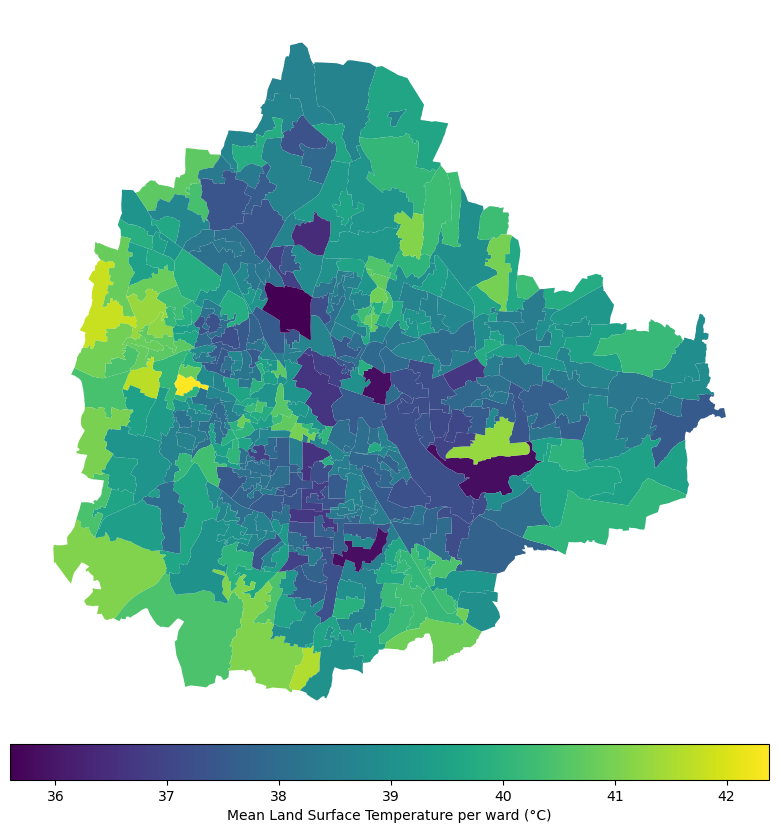

In [39]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# IMPORTANT: capture fig and ax
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.1)

df_wards_merged_summer.plot(
    column="mean",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={
        "label": "Mean Land Surface Temperature per ward (°C)",
        "orientation": "horizontal"
    },
)
plt.savefig(fig_path)
ax.set_axis_off()
plt.savefig(fig_path, dpi = 300, bbox_inches = "tight")
plt.show()

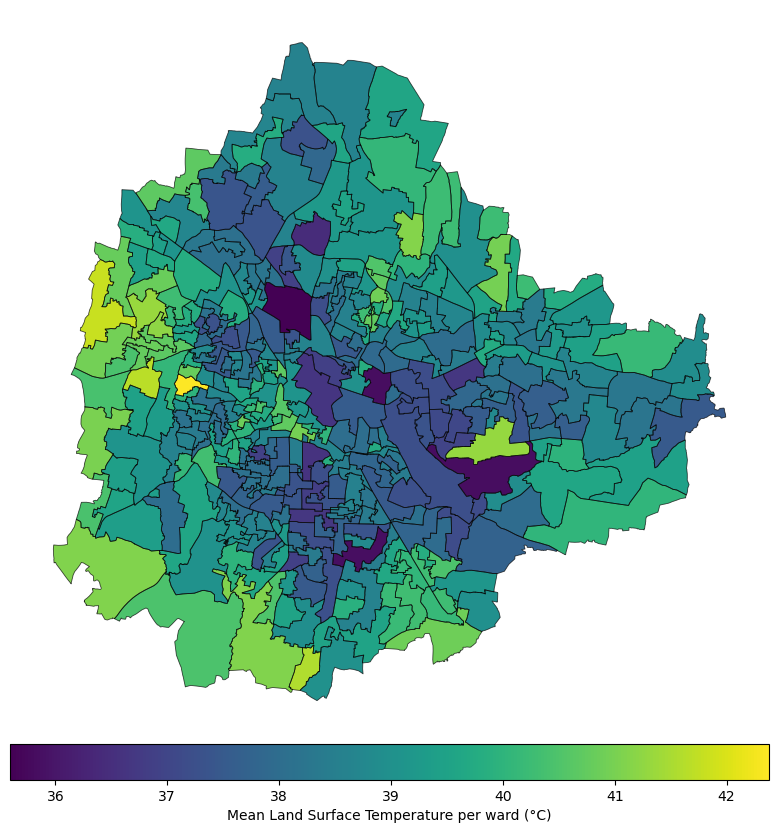

In [43]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# IMPORTANT: capture fig and ax
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.1)

df_wards_merged_summer.plot(
    column="mean",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={
        "label": "Mean Land Surface Temperature per ward (°C)",
        "orientation": "horizontal"
    },
)

df_wards_merged_summer.boundary.plot(
    ax=ax,
    linewidth=0.6,
    color="black",
    alpha=0.7
)

plt.savefig(fig_path)
ax.set_axis_off()
plt.savefig(fig_path, dpi = 300, bbox_inches = "tight")
plt.show()

In [ ]:
## Also add tiny labels and change the color bar a bit:
## First, need to reproject

In [44]:
df_wards_summer_reproj = df_wards_merged_summer.to_crs(epsg=3857)

In [45]:
fig_path =  BASE_DIR / 'images' /'lst_ward_summer_bang_band10_full.png'

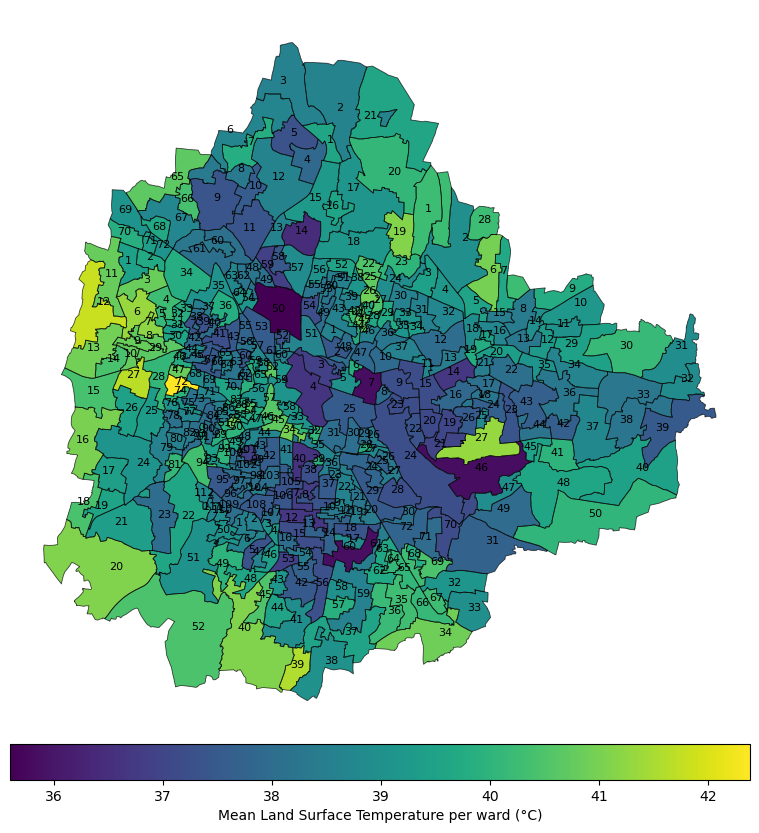

In [49]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# IMPORTANT: capture fig and ax
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

df_wards_summer_reproj["label_point"] = df_wards_summer_reproj.geometry.representative_point()

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.1)

df_wards_summer_reproj.plot(
    column="mean",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={
        "label": "Mean Land Surface Temperature per ward (°C)",
        "orientation": "horizontal"
    },
)

df_wards_summer_reproj.boundary.plot(
    ax=ax,
    linewidth=0.6,
    color="black",
    alpha=0.7
)


for _, row in df_wards_summer_reproj.iterrows():
    ax.text(
        row.label_point.x,
        row.label_point.y,
        row["ward_id"],
        fontsize=8,
        ha="center",
    )

ax.set_axis_off()
plt.savefig(fig_path, dpi = 300, bbox_inches = "tight")
plt.show()

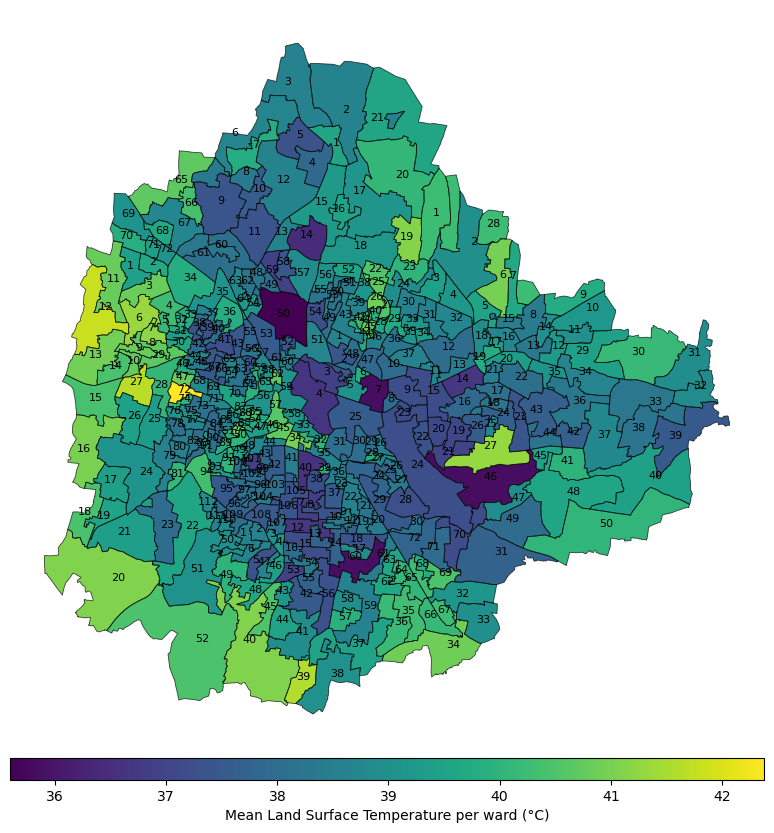

In [51]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# IMPORTANT: capture fig and ax
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

df_wards_summer_reproj["label_point"] = df_wards_summer_reproj.geometry.representative_point()

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="3%", pad=0.1)

df_wards_summer_reproj.plot(
    column="mean",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={
        "label": "Mean Land Surface Temperature per ward (°C)",
        "orientation": "horizontal"
    },
)

df_wards_summer_reproj.boundary.plot(
    ax=ax,
    linewidth=0.6,
    color="black",
    alpha=0.7
)


for _, row in df_wards_summer_reproj.iterrows():
    ax.text(
        row.label_point.x,
        row.label_point.y,
        row["ward_id"],
        fontsize=8,
        ha="center",
    )

ax.set_axis_off()
plt.savefig(fig_path, dpi = 300, bbox_inches = "tight")
plt.show()

## References

Gandhi, Ujaval, 2021. End-to-End Google Earth Engine Course. Spatial Thoughts. https://courses.spatialthoughts.com/end-to-end-gee.html

Wu, Q. (2023). Earth Engine and Geemap. Geospatial Datascience with Python (1st ed.). Locate Press.  https://doi.org/10.21105/joss.02305 